In [123]:
# !pip install -U matplotlib
# !pip install pandas 
# !pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 20.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]2m5/6 [optuna]]


# Diccionario de datos — Instacart Market Basket Analysis

Dataset público de Instacart (2017): más de 3 millones de órdenes de supermercado de unos 200.000 usuarios anónimos, cada uno con entre 4 y 100 órdenes. Es lo más parecido a Tipti que existe en datos públicos: compras de supermercado por app, hechas por shoppers y entregadas a domicilio.

- **Fuente:** Kaggle, espejo `psparks/instacart-market-basket-analysis`
- **Licencia:** uso no comercial. Los datos crudos **no** se suben al repositorio (`data/` está en `.gitignore`).

---

## 1. Modelo de datos

El dataset es relacional, como un modelo estrella de BI:

- **Hechos:** `order_products__prior` y `order_products__train` (qué producto va en qué orden).
- **Dimensiones:** `orders` (quién y cuándo), `products`, `aisles`, `departments`.

```
departments ──┐
              ├── products ──── order_products__prior / __train ──── orders
aisles ───────┘   (product_id)        (order_id)                     (user_id)
```

### Cabecera y detalle

`orders` y `order_products` funcionan como la cabecera y el detalle de una factura:

- **`orders` (cabecera):** una fila por orden. Dice quién compró y cuándo, pero no qué compró.
- **`order_products__*` (detalle):** una fila por cada producto dentro de una orden. Dice qué se compró.

Se unen por `order_id`.

### `prior` y `train` no son muestras: separan el tiempo

```
Usuario 1 — sus órdenes en orders:
order_number:  1      2      3   ...   10     11
eval_set:      prior  prior  prior ... prior  train
               └──── detalle en __prior ────┘  └ detalle en __train
                     (su historial)              (su última orden)
```

| eval_set | Qué contiene | Uso en el proyecto |
|---|---|---|
| `prior` | Todas las órdenes de cada usuario excepto la última | **Entrenar** |
| `train` | La última orden de ~131.000 usuarios | **Evaluar (test)**: el modelo nunca la ve al entrenar |
| `test` | La última orden de ~75.000 usuarios, sin productos (respuesta de la competencia) | No se usa |

Esto simula la vida real: con todo lo que el cliente compró antes, ¿adivinamos qué pedirá la próxima vez?

### Jerarquía del catálogo

```
departamento (21)  →  pasillo (134)  →  producto (~50.000)
```

Es la misma estructura de categorías de una app de supermercado, y permite recomendar o segmentar en el nivel que convenga.

---

## 2. Las 6 tablas

| Tabla | Filas aprox. | Qué es | Para qué la usamos |
|---|---|---|---|
| `orders` | 3,4 M | Cabecera de cada orden: quién, cuál de sus órdenes, día, hora y días desde la anterior | Ordenar el historial en el tiempo (validación temporal, SASRec), contexto (hora/día), separar train/test (`eval_set`) |
| `order_products__prior` | 32 M | Detalle del historial: productos de cada orden pasada | **Entrenar**: matriz de ALS, reglas de asociación, popularidad, recompra |
| `order_products__train` | 1,4 M | Detalle de la última orden de ~131 mil usuarios | **Evaluar** (test) |
| `products` | ~50 mil | Catálogo: nombre del producto y códigos de pasillo y departamento | Traducir IDs a nombres, cold-start, modelos de contenido |
| `aisles` | 134 | Diccionario de pasillos: código → nombre ("fresh fruits") | Análisis por pasillo, segmentación de usuarios |
| `departments` | 21 | Diccionario de departamentos: código → nombre ("produce", "dairy eggs") | Nivel más alto de la jerarquía del catálogo |

---

## 3. Columnas

### `orders` (cabecera)

| Columna | Tipo | Qué es | Para qué nos sirve |
|---|---|---|---|
| `order_id` | int32 | ID único de la orden | Llave para unir con el detalle |
| `user_id` | int32 | ID anónimo del cliente | Construir el historial de cada usuario |
| `eval_set` | texto | `prior`, `train` o `test` | Separar pasado y futuro |
| `order_number` | int16 | 1ª, 2ª, 3ª… orden del usuario | Ordenar en el tiempo; validación temporal y modelos secuenciales |
| `order_dow` | int8 | Día de la semana (0 a 6) | Contexto: fin de semana frente a entre semana |
| `order_hour_of_day` | int8 | Hora del pedido (0 a 23) | Contexto: compra de mañana frente a la de noche |
| `days_since_prior_order` | float32 | Días desde la orden anterior (máximo 30; vacío en la 1ª orden) | Frecuencia del cliente, ciclo de recompra |

### `order_products__prior` / `order_products__train` (detalle)

| Columna | Tipo | Qué es | Para qué nos sirve |
|---|---|---|---|
| `order_id` | int32 | A qué orden pertenece | Unir con `orders` para saber quién y cuándo |
| `product_id` | int32 | Qué producto | El "ítem" de la matriz usuario × producto |
| `add_to_cart_order` | int16 | Posición en que se agregó al carrito (1º, 2º…) | Secuencia dentro de la canasta; recomendaciones en el carrito |
| `reordered` | int8 | 1 si ya lo había comprado antes, 0 si es nuevo | Tasa de recompra; distinguir hábito de descubrimiento |

### `products`, `aisles`, `departments` (catálogo)

| Columna | Tabla | Qué es |
|---|---|---|
| `product_id` | products | ID único del producto |
| `product_name` | products | Nombre en texto ("Banana", "Organic Whole Milk") |
| `aisle_id` | products, aisles | Código del pasillo |
| `department_id` | products, departments | Código del departamento |
| `aisle` | aisles | Nombre del pasillo ("fresh fruits") |
| `department` | departments | Nombre del departamento ("produce") |

`products` solo trae los **códigos** de pasillo y departamento; los **nombres** están en `aisles` y `departments`. Por eso se unen:

```
products:     24852 | Banana | 24 | 4
aisles:       24 | fresh fruits
departments:  4  | produce
resultado:    24852 | Banana | 24 | fresh fruits | 4 | produce
```

Para los algoritmos bastan los códigos. Los nombres sirven para el análisis exploratorio, para leer las recomendaciones y para los embeddings de texto en cold-start.

---

## 4. Limitaciones a tener en cuenta

- **No hay fechas reales**, solo `order_number` y `days_since_prior_order`. La validación temporal se hace por número de orden.
- **`days_since_prior_order` está topado en 30.** Un cliente que volvió a los 90 días aparece como 30; no sirve para medir abandono largo.
- **No hay precios**, así que no se pueden calcular métricas de ingreso.
- **No hay marca ni demografía.** El cold-start de usuario se resuelve por comportamiento (primeras compras, segmentos), no por atributos personales.
- **No es una muestra aleatoria** de los usuarios de Instacart; los resultados ilustran el método, no el negocio real.

---

## 5. Decisiones de carga

- **Tipos de datos livianos** (`int32`, `int16`, `int8` en lugar de `int64`): bajan la memoria de ~1 GB a ~300 MB y permiten trabajar en una laptop. Es una decisión de costo, igual que el costo de inferencia en producción.
- **Controles de integridad referencial** antes de modelar: todo `product_id` vendido existe en el catálogo y todo `order_id` del detalle existe en `orders`. Los nulos de `days_since_prior_order` deben coincidir con el número de usuarios (una primera orden por usuario).

In [7]:
csv

{'departments': PosixPath('/home/ricardorobayom95/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1/departments.csv'),
 'orders': PosixPath('/home/ricardorobayom95/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1/orders.csv'),
 'order_products__prior': PosixPath('/home/ricardorobayom95/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1/order_products__prior.csv'),
 'order_products__train': PosixPath('/home/ricardorobayom95/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1/order_products__train.csv'),
 'aisles': PosixPath('/home/ricardorobayom95/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1/aisles.csv'),
 'products': PosixPath('/home/ricardorobayom95/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1/products.csv')}

In [38]:
# =====================================================================
# BLOQUE 1 — CARGA DE DATOS
# =====================================================================
# NEGOCIO: Instacart es lo más parecido a Tipti que existe en datos públicos:
#   compras de supermercado por app, hechas por shoppers y entregadas a domicilio.
#   Cada fila que cargamos es una decisión real de compra de un hogar.
#
# TÉCNICO: el dataset es RELACIONAL, como un modelo estrella de BI:
#   - Hechos:      order_products (qué producto va en qué orden)
#   - Dimensiones: orders (quién y cuándo), products, aisles, departments
#   Se unen por llaves: order_id, product_id, aisle_id, department_id.
# =====================================================================
import pandas as pd
import numpy as np
from pathlib import Path
import kagglehub

# --- 1.1 Ubicar los archivos ----------------------------------------
# kagglehub descarga una sola vez y luego usa la copia en caché,
# así que volver a correr esta línea no vuelve a descargar.
ruta = Path(kagglehub.dataset_download("psparks/instacart-market-basket-analysis"))
csv = {f.stem: f for f in ruta.rglob("*.csv")}
print("Archivos:", sorted(csv))

# --- 1.2 Tipos de datos livianos -------------------------------------
# TÉCNICO: por defecto pandas usa int64 (8 bytes por número). Un ID de
#   producto cabe en int32 (4 bytes) y un día de semana en int8 (1 byte).
#   Con 32 millones de filas, eso baja la memoria de ~1 GB a ~300 MB.
# NEGOCIO: es lo que permite trabajar en una laptop en lugar de pagar un
#   clúster. Es una decisión de costo, igual que el "costo de inferencia"
#   que menciona la vacante.
tipos_orders = {"order_id": "int32", "user_id": "int32", "order_number": "int16",
                "order_dow": "int8", "order_hour_of_day": "int8",
                "days_since_prior_order": "float32"}   # float porque la 1ª orden no tiene valor (NaN)
tipos_op = {"order_id": "int32", "product_id": "int32",
            "add_to_cart_order": "int16", "reordered": "int8"}

orders   = pd.read_csv(csv["orders"], dtype=tipos_orders)
prior    = pd.read_csv(csv["order_products__prior"], dtype=tipos_op)
train    = pd.read_csv(csv["order_products__train"], dtype=tipos_op)
products = pd.read_csv(csv["products"])
aisles   = pd.read_csv(csv["aisles"])
depts    = pd.read_csv(csv["departments"])

# --- 1.3 Enriquecer el catálogo --------------------------------------
# NEGOCIO: un producto con su pasillo y departamento se puede explicar
#   ("snacks salados", "lácteos"). Esto alimenta luego el cold-start y
#   los modelos basados en contenido.
products = (products.merge(aisles, on="aisle_id")
                    .merge(depts, on="department_id"))

# --- 1.4 Inventario de tablas ----------------------------------------
def resumen(nombre, df):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"{nombre:10s} {df.shape[0]:>12,} filas × {df.shape[1]} cols  | {mb:7.1f} MB")

for n, d in [("orders", orders), ("prior", prior), ("train", train),
             ("products", products), ("aisles", aisles), ("depts", depts)]:
    resumen(n, d)

# --- 1.5 La columna clave: eval_set ----------------------------------
# TÉCNICO: Instacart ya separó el tiempo por nosotros.
#   prior → todas las órdenes anteriores de cada usuario (historial, para entrenar)
#   train → la ÚLTIMA orden de ~131 mil usuarios (nuestro test)
#   test  → la última orden de otros 75 mil, SIN productos (era la competencia; no la usamos)
# NEGOCIO: esto simula la vida real: con todo lo que compraste antes,
#   ¿adivino qué vas a pedir la próxima vez?
print("\nÓrdenes por eval_set:")
print(orders.eval_set.value_counts())

# --- 1.6 Control de calidad de llaves --------------------------------
# TÉCNICO: verificamos integridad referencial (tu terreno DAMA):
#   ¿todo producto vendido existe en el catálogo?, ¿toda orden existe en orders?
# NEGOCIO: si las llaves no cuadran, las métricas mienten.
print("\nProductos de prior sin catálogo:", (~prior.product_id.isin(products.product_id)).sum())
print("Órdenes de prior sin cabecera:   ", (~prior.order_id.isin(orders.order_id)).sum())
print("Nulos en days_since_prior_order: ", orders.days_since_prior_order.isna().sum(),
      "(= primeras órdenes, es esperado)")

products.head()

Archivos: ['aisles', 'departments', 'order_products__prior', 'order_products__train', 'orders', 'products']
orders        3,421,083 filas × 7 cols  |   266.8 MB
prior        32,434,489 filas × 4 cols  |   356.8 MB
train         1,384,617 filas × 4 cols  |    15.2 MB
products         49,688 filas × 6 cols  |    12.4 MB
aisles              134 filas × 2 cols  |     0.0 MB
depts                21 filas × 2 cols  |     0.0 MB

Órdenes por eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Productos de prior sin catálogo: 0
Órdenes de prior sin cabecera:    0
Nulos en days_since_prior_order:  206209 (= primeras órdenes, es esperado)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [39]:
display(orders.head())
display(prior.head())

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [45]:
prior[prior['order_id'] == 2]

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0


In [48]:
prior.merge(products[["product_id", "department"]], on="product_id")

,order_id,product_id,add_to_cart_order,reordered,department
0,2,33120,1,1,dairy eggs
1,2,28985,2,1,produce
2,2,9327,3,0,pantry
3,2,45918,4,1,pantry
4,2,30035,5,0,pantry
...,...,...,...,...,...
32434484,3421083,39678,6,1,household
32434485,3421083,11352,7,0,snacks
32434486,3421083,4600,8,0,frozen
32434487,3421083,24852,9,1,produce


2.1 Órdenes por usuario:
count    206209.0
mean         16.6
std          16.7
min           4.0
25%           6.0
50%          10.0
75%          20.0
max         100.0

   Distribución en el extremo bajo (historial corto):
order_number
4     11.6
5      9.5
6      7.8
7      6.7
8      5.7
9      4.9
10     4.4
11     3.8
   Usuarios con ≤ 5 órdenes: 21.1%

2.2 Productos por orden:
count    3214874.0
mean          10.1
std            7.5
min            1.0
25%            5.0
50%            8.0
75%           14.0
max          145.0 

2.3 Tasa de recompra global: 59.0%
   Departamentos con MÁS recompra: {'produce': 0.65, 'beverages': 0.65, 'dairy eggs': 0.67}
   Departamentos con MENOS recompra: {'personal care': 0.32, 'pantry': 0.35, 'international': 0.37} 

2.4 El 1 % de productos concentra el 42.8% de las ventas
   El 10 % de productos concentra el 81.4% de las ventas
   Productos comprados por < 5 usuarios: 6.7%

2.5 Días entre órdenes — más frecuentes: {30.0: 369323, 7.0: 320608, 6

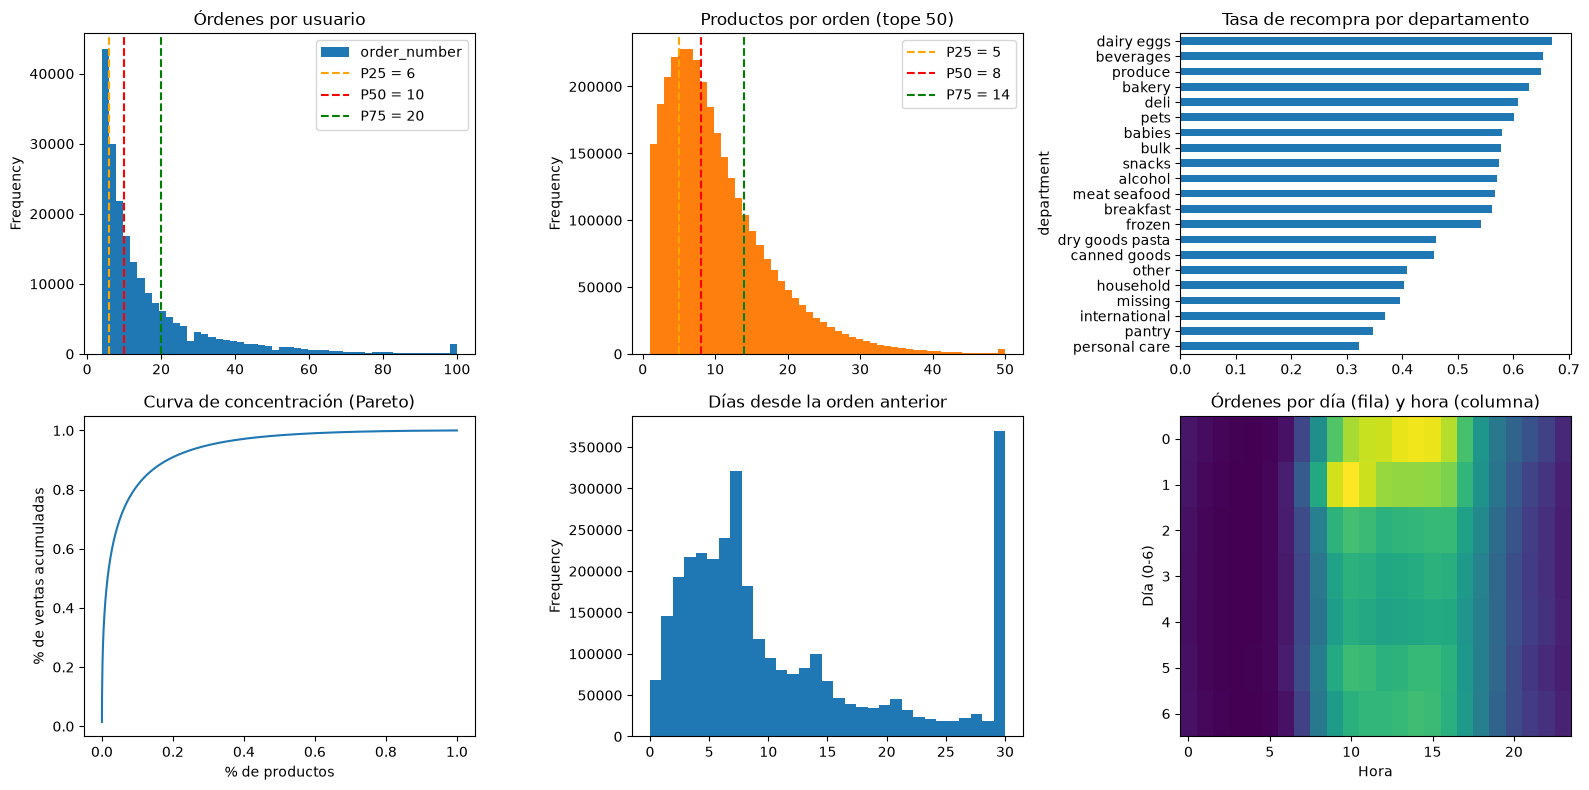

2.7 Top 10 productos:
          product_name                      aisle  ventas
                Banana               fresh fruits  472565
Bag of Organic Bananas               fresh fruits  379450
  Organic Strawberries               fresh fruits  264683
  Organic Baby Spinach packaged vegetables fruits  241921
  Organic Hass Avocado               fresh fruits  213584
       Organic Avocado               fresh fruits  176815
           Large Lemon               fresh fruits  152657
          Strawberries               fresh fruits  142951
                 Limes               fresh fruits  140627
    Organic Whole Milk                       milk  137905


In [43]:
# ---------------------------------------------------------------------
# Función auxiliar: dibuja líneas verticales en los percentiles 25, 50 y 75
# TÉCNICO: los cuartiles dividen a la población en 4 grupos de igual tamaño.
#   P50 es la mediana: el usuario "típico", más robusta que el promedio
#   cuando hay valores extremos (usuarios con 100 órdenes, canastas de 80).
# NEGOCIO: permite decir "el 25 % de los clientes tiene ≤ X órdenes",
#   que es como se definen segmentos y umbrales con evidencia.
# ---------------------------------------------------------------------
def lineas_cuartiles(serie, eje):
    colores = {0.25: "orange", 0.50: "red", 0.75: "green"}
    for q, color in colores.items():
        valor = serie.quantile(q)
        eje.axvline(valor, color=color, linestyle="--", linewidth=1.5,
                    label=f"P{int(q*100)} = {valor:.0f}")
    eje.legend()
    
# =====================================================================
# BLOQUE 2 — ANÁLISIS EXPLORATORIO (EDA)
# Usa: orders, prior, products (del bloque 1)
# =====================================================================
import matplotlib.pyplot as plt

# Unimos el detalle con la cabecera para saber QUIÉN compró cada producto.
# TÉCNICO: merge de 32 M filas; solo traemos las columnas necesarias para ahorrar memoria.
hist = prior.merge(orders[["order_id", "user_id", "order_number"]], on="order_id")

fig, ax = plt.subplots(2, 3, figsize=(16, 8))

# ---------------------------------------------------------------------
# 2.1 ¿CUÁNTO HISTORIAL TIENE CADA USUARIO?
# NEGOCIO: un cliente con 4 órdenes se conoce poco; uno con 80, muy bien.
# TÉCNICO: define cuántos usuarios estarán en "cold-start parcial".
# DECISIÓN: si muchos tienen pocas órdenes, la popularidad por segmento
#           será clave para ellos.
# ---------------------------------------------------------------------
ord_x_user = orders.groupby("user_id").order_number.max()
print("2.1 Órdenes por usuario:")
print(ord_x_user.describe(percentiles=[.25, .5, .75]).round(1).to_string())
# % de clientes por cantidad de entregas en order ascendente - cuantos clientes pueden no ser representados correctamiente por ASL
print("\n   Distribución en el extremo bajo (historial corto):")
print((ord_x_user.value_counts(normalize=True).sort_index().head(8) * 100).round(1).to_string())
### cantidad de clientes que no serían buenos aptos ASL
print(f"   Usuarios con ≤ 5 órdenes: {(ord_x_user <= 5).mean():.1%}\n")

ord_x_user.plot.hist(bins=50, ax=ax[0, 0], title="Órdenes por usuario")
lineas_cuartiles(ord_x_user, ax[0, 0])

# ---------------------------------------------------------------------
# 2.2 ¿QUÉ TAN GRANDE ES UNA CANASTA?
# NEGOCIO: el tamaño típico de canasta dice cuántos productos tiene
#          sentido recomendar (¿10 es mucho o poco?).
# TÉCNICO: también limita el recall@10. Si la canasta trae 20 productos,
#          10 recomendaciones nunca pueden tener recall 100 %.
# ---------------------------------------------------------------------
canasta = prior.groupby("order_id").size()
print("2.2 Productos por orden:")
print(canasta.describe(percentiles=[.25, .5, .75]).round(1).to_string(), "\n")
canasta.clip(upper=50).plot.hist(bins=50, ax=ax[0, 1], title="Productos por orden (tope 50)")
canasta.clip(upper=50).plot.hist(bins=50, ax=ax[0, 1], title="Productos por orden (tope 50)")
lineas_cuartiles(canasta, ax[0, 1])

# ---------------------------------------------------------------------
# 2.3 ¿CUÁNTO SE RECOMPRA?  ← la pregunta más importante
# NEGOCIO: si la mayoría de la canasta son productos habituales, el carrusel
#          "compra de nuevo" es el que más vende.
# TÉCNICO: explica por qué la línea base de recompra le ganó a ALS y por qué
#          NO filtramos los productos ya comprados al recomendar.
# ---------------------------------------------------------------------
tasa_recompra = prior.reordered.mean()
print(f"2.3 Tasa de recompra global: {tasa_recompra:.1%}")

rec_depto = (prior.merge(products[["product_id", "department"]], on="product_id")
                  .groupby("department").reordered.mean().sort_values())
print("   Departamentos con MÁS recompra:", rec_depto.tail(3).round(2).to_dict())
print("   Departamentos con MENOS recompra:", rec_depto.head(3).round(2).to_dict(), "\n")
rec_depto.plot.barh(ax=ax[0, 2], title="Tasa de recompra por departamento")

# ---------------------------------------------------------------------
# 2.4 POPULARIDAD Y COLA LARGA
# NEGOCIO: pocos productos concentran la mayoría de ventas; el resto
#          ("cola larga") se vende poco pero es donde está la personalización.
# TÉCNICO: productos comprados por muy pocos usuarios son ruido para ALS:
#          no hay de quién aprender. Candidatos a filtrar.
# ---------------------------------------------------------------------
ventas = prior.product_id.value_counts()
top1 = ventas.head(int(len(ventas) * 0.01)).sum() / ventas.sum()
top10 = ventas.head(int(len(ventas) * 0.10)).sum() / ventas.sum()
usuarios_x_prod = hist.groupby("product_id").user_id.nunique()
print(f"2.4 El 1 % de productos concentra el {top1:.1%} de las ventas")
print(f"   El 10 % de productos concentra el {top10:.1%} de las ventas")
print(f"   Productos comprados por < 5 usuarios: {(usuarios_x_prod < 5).mean():.1%}\n")
ax[1, 0].plot(np.arange(len(ventas)) / len(ventas), ventas.cumsum().values / ventas.sum())
ax[1, 0].set_title("Curva de concentración (Pareto)")
ax[1, 0].set_xlabel("% de productos"); ax[1, 0].set_ylabel("% de ventas acumuladas")

# ---------------------------------------------------------------------
# 2.5 ¿CADA CUÁNTO COMPRAN?
# NEGOCIO: el ciclo de compra (semanal, mensual) dice CUÁNDO enviar una
#          notificación o activar el carrusel de recompra.
# TÉCNICO: los picos en 7 y 30 días son hábitos reales; el 30 además
#          incluye "30 o más" (dato topado).
# ---------------------------------------------------------------------
dias = orders.days_since_prior_order.dropna()
print("2.5 Días entre órdenes — más frecuentes:", dias.value_counts().head(5).to_dict(), "\n")
dias.plot.hist(bins=31, ax=ax[1, 1], title="Días desde la orden anterior")

# ---------------------------------------------------------------------
# 2.6 ¿CUÁNDO COMPRAN?
# NEGOCIO: horas pico para capacidad de shoppers y para saber cuándo
#          mostrar promociones.
# TÉCNICO: hora y día son "contexto"; ALS no los usa, pero Two-Tower sí puede.
# ---------------------------------------------------------------------
calor = orders.pivot_table(index="order_dow", columns="order_hour_of_day",
                           values="order_id", aggfunc="count")
ax[1, 2].imshow(calor, aspect="auto", cmap="viridis")
ax[1, 2].set_title("Órdenes por día (fila) y hora (columna)")
ax[1, 2].set_xlabel("Hora"); ax[1, 2].set_ylabel("Día (0-6)")

plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------
# 2.7 ¿QUÉ SE VENDE MÁS?
# NEGOCIO: esto ES la línea base de popularidad; es lo que vería un usuario
#          nuevo sin personalización.
# ---------------------------------------------------------------------
top_prod = (ventas.head(10).rename("ventas").reset_index()
                  .merge(products[["product_id", "product_name", "aisle"]], on="product_id"))
print("2.7 Top 10 productos:")
print(top_prod[["product_name", "aisle", "ventas"]].to_string(index=False))

# BLOQUE 3 — PREPARACIÓN DE DATOS

Usamos: orders, train, hist (bloque 2: prior + user_id + order_number)


In [67]:
from scipy.sparse import csr_matrix

N_USUARIOS = 20_000          # muestra para iterar rápido; luego se puede subir
MIN_USUARIOS_X_PROD = 5      # decisión del EDA (2.4): productos con menos usuarios son ruido

# ---------------------------------------------------------------------
# 3.1 MUESTRA DE USUARIOS
# TÉCNICO: solo usuarios con eval_set == 'train', porque son los únicos
#   cuya última orden tiene productos conocidos (sin eso no hay test).
#   Semilla fija = resultados reproducibles (requisito para el README).
# NEGOCIO: 20 mil clientes es una muestra grande; en producción se entrena
#   con todos, pero para decidir método y parámetros basta una muestra.
# ---------------------------------------------------------------------
usuarios_elegibles = orders.loc[orders.eval_set == "train", "user_id"].unique()
rng = np.random.default_rng(42)
muestra = rng.choice(usuarios_elegibles, size=N_USUARIOS, replace=False)
h = hist[hist.user_id.isin(muestra)]
display(h.head(15))

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number
17,4,46842,1,0,178520,36
18,4,26434,2,1,178520,36
19,4,39758,3,1,178520,36
20,4,27761,4,1,178520,36
21,4,10054,5,1,178520,36
22,4,21351,6,1,178520,36
23,4,22598,7,1,178520,36
24,4,34862,8,1,178520,36
25,4,40285,9,1,178520,36
26,4,17616,10,1,178520,36


In [68]:
# ---------------------------------------------------------------------
# 3.2 DIVISIÓN TEMPORAL EN TRES PARTES
#
#   órdenes:  1  2  3 ... n-2 | n-1        | n
#             ── ENTRENAR ──  | VALIDACIÓN | TEST
#                              (ajustar     (medir UNA vez,
#                               parámetros)  al final)
#
# TÉCNICO: nunca se divide al azar en recomendación: el modelo vería
#   compras "del futuro". Se corta por tiempo, como pasaría en producción.
#   La validación existe para ajustar sin tocar el test.
# NEGOCIO: simula el día a día: con lo que sabemos hasta hoy,
#   ¿acertamos la próxima compra del cliente?
# ---------------------------------------------------------------------
ultima_prior = h.groupby("user_id").order_number.transform("max")
h_entreno = h[h.order_number < ultima_prior]     # órdenes 1 … n-2
h_valid   = h[h.order_number == ultima_prior]    # orden n-1

# Genero listas de canastas de compra para validar los resutados
valid = h_valid.groupby("user_id")['product_id'].apply(set)

# Genero listas de canastas de compra para el test
test = (train.merge(orders.loc[orders['eval_set'] == "train", ["order_id", "user_id"]], on="order_id")
             .loc[lambda d: d['user_id'].isin(muestra)]
             .groupby("user_id")['product_id'].apply(set))   # orden n

In [91]:

# ---------------------------------------------------------------------
# 3.3 FILTRAR LA COLA LARGA
# TÉCNICO: un producto comprado por 1-4 usuarios no tiene de quién
#   "aprender" sus gustos ocultos; su vector sería casi aleatorio y mete ruido.
#   El filtro se calcula SOLO con datos de entrenamiento (si usáramos el
#   test para decidir qué filtrar, sería una fuga de información).
# NEGOCIO: esos productos no desaparecen del catálogo; simplemente ALS no
#   los recomienda. Les sirven la popularidad o el modelo de contenido.
# ---------------------------------------------------------------------
def filtrar_cola(df, minimo=MIN_USUARIOS_X_PROD):
    usuarios_x_prod = df.groupby("product_id")['user_id'].nunique()
    validos = usuarios_x_prod[usuarios_x_prod >= minimo].index
    print(f"   Productos: {df['product_id'].nunique():,} → {len(validos):,} tras el filtro | Productos excluidos por no se venden a mas de 5 personas: {np.round(len(validos)/df['product_id'].nunique(),2)*100}")
    return df[df['product_id'].isin(validos)]

# ---------------------------------------------------------------------
# 3.4 AGREGAR: de "una fila por compra" a "veces que compró cada producto"
# TÉCNICO: esto es el feedback IMPLÍCITO: no hay calificación, solo la
#   frecuencia. Comprar leche 20 veces = señal fuerte; 1 vez = débil.
# NEGOCIO: es la forma de medir "preferencia" sin preguntarle nada al cliente.
# ---------------------------------------------------------------------
def agregar(df):
    return df.groupby(["user_id", "product_id"]).size().rename("veces").reset_index()

# ---------------------------------------------------------------------
# 3.5 MATRIZ DISPERSA usuario × producto
# TÉCNICO: ALS trabaja con índices 0, 1, 2… no con IDs de Instacart, así
#   que creamos diccionarios de traducción. La matriz es "dispersa"
#   (csr_matrix): solo guarda las celdas con compras (>99 % están vacías).
# NEGOCIO: esta matriz es la "memoria" del sistema: quién compró qué y cuánto.
# ---------------------------------------------------------------------
def construir_matriz(inter):
    usuarios, productos = inter['user_id'].unique(), inter['product_id'].unique()
    u2i = {u: i for i, u in enumerate(usuarios)}
    p2i = {p: i for i, p in enumerate(productos)}
    i2p = np.array(productos)
    M = csr_matrix((inter['veces'].values.astype("float32"),
                    (inter['user_id'].map(u2i).values, inter['product_id'].map(p2i).values)),
                   shape=(len(usuarios), len(productos)))
    print(f"   Matriz {M.shape[0]:,} × {M.shape[1]:,} | celdas con compras {M.nnz:,} "
          f"| densidad {M.nnz / (M.shape[0] * M.shape[1]):.4%}")
    return M, u2i, p2i, i2p

# Dos matrices, cada una con su propósito:
print("MATRIZ PARA AJUSTAR (órdenes 1 … n-2):")
inter_aj = agregar(filtrar_cola(h_entreno))
M_aj, u2i_aj, p2i_aj, i2p_aj = construir_matriz(inter_aj)

print("\nMATRIZ FINAL (órdenes 1 … n-1, todo el historial):")
inter_fin = agregar(filtrar_cola(h))
M_fin, u2i_fin, p2i_fin, i2p_fin = construir_matriz(inter_fin)

# ---------------------------------------------------------------------
# 3.6 CONTROLES DE CALIDAD (antes de entrenar, siempre)
# ---------------------------------------------------------------------
# a) Sin fuga: ninguna orden de validación aparece en el entrenamiento de ajuste
fuga = set(h_valid.order_id) & set(h_entreno.order_id)
print(f"\n3.6 Órdenes de validación filtradas al entrenamiento: {len(fuga)}  (debe ser 0)")

# b) Cobertura: ¿qué % de lo que compran en el test existe en nuestro catálogo?
#    NEGOCIO: es el TECHO del modelo. Si un producto no está en la matriz,
#    ALS nunca podrá recomendarlo, por bueno que sea.
cat = set(i2p_fin)
cubiertos = sum(len(s & cat) for s in test) / sum(len(s) for s in test)
print(f"    Cobertura del test por el catálogo de ALS: {cubiertos:.1%}")

# c) Tamaños de cada conjunto
print(f"    Usuarios — ajuste: {len(u2i_aj):,} | validación: {len(valid):,} | test: {len(test):,}")

MATRIZ PARA AJUSTAR (órdenes 1 … n-2):
   Productos: 40,624 → 21,400 tras el filtro | Productos excluidos por no se venden a mas de 5 personas: 53.0
   Matriz 19,999 × 21,400 | celdas con compras 1,169,518 | densidad 0.2733%

MATRIZ FINAL (órdenes 1 … n-1, todo el historial):
   Productos: 41,248 → 22,123 tras el filtro | Productos excluidos por no se venden a mas de 5 personas: 54.0
   Matriz 20,000 × 22,123 | celdas con compras 1,255,141 | densidad 0.2837%

3.6 Órdenes de validación filtradas al entrenamiento: 0  (debe ser 0)
    Cobertura del test por el catálogo de ALS: 97.2%
    Usuarios — ajuste: 19,999 | validación: 20,000 | test: 20,000


In [92]:
# ---------------------------------------------------------------------
# 3.7 REPORTE DE PREPARACIÓN — números convertidos en insights
# NEGOCIO: un resultado sin interpretación no sirve para decidir.
#   Este reporte es el que se copia al README.
# ---------------------------------------------------------------------
def reporte_preparacion(h_sin_filtro, inter_filtrado, M, u2i, i2p, test, usuarios_muestra):
    inter_sin = agregar(h_sin_filtro)

    # Filtro de cola larga
    prod_antes, prod_desp = inter_sin.product_id.nunique(), M.shape[1]
    celdas_antes, celdas_desp = len(inter_sin), M.nnz
    pct_catalogo = 1 - prod_desp / prod_antes
    pct_interacc = 1 - celdas_desp / celdas_antes

    # Densidad
    dens_antes = celdas_antes / (inter_sin.user_id.nunique() * prod_antes)
    dens_desp  = celdas_desp / (M.shape[0] * M.shape[1])

    # Cobertura del test
    cat = set(i2p)
    cobertura = sum(len(s & cat) for s in test) / sum(len(s) for s in test)

    # Usuarios sin fila en la matriz (cold-start)
    perdidos = len(usuarios_muestra) - len(u2i)

    print("=" * 70)
    print("REPORTE DE PREPARACIÓN")
    print("=" * 70)
    print(f"\n1. FILTRO DE COLA LARGA (productos con < {MIN_USUARIOS_X_PROD} compradores)")
    print(f"   Catálogo: {prod_antes:,} → {prod_desp:,} productos  (−{pct_catalogo:.1%})")
    print(f"   Interacciones: {celdas_antes:,} → {celdas_desp:,}  (−{pct_interacc:.1%})")
    print(f"   → INSIGHT: se elimina el {pct_catalogo:.0%} del catálogo perdiendo solo el "
          f"{pct_interacc:.1%} de las compras. La mayoría de productos casi no se vende.")

    print(f"\n2. DENSIDAD DE LA MATRIZ")
    print(f"   {dens_antes:.3%} → {dens_desp:.3%}  (×{dens_desp/dens_antes:.1f})")
    print(f"   → INSIGHT: la matriz queda más compacta y con menos ruido; "
          f"ALS entrena más rápido y con vectores más confiables.")

    print(f"\n3. COBERTURA DEL TEST")
    print(f"   {cobertura:.1%} de lo comprado en la última orden existe en el catálogo de ALS")
    print(f"   → INSIGHT: es el TECHO del modelo. El {1-cobertura:.1%} restante son productos "
          f"raros o nuevos que ALS no puede recomendar: los cubre popularidad o contenido.")

    print(f"\n4. USUARIOS SIN PERFIL EN LA MATRIZ")
    print(f"   {perdidos:,} de {len(usuarios_muestra):,} usuarios ({perdidos/len(usuarios_muestra):.2%})")
    print(f"   → INSIGHT: todo su historial era de cola larga. Son cold-start reales: "
          f"necesitan un respaldo (popularidad).")
    print("=" * 70)

    return {"pct_catalogo_filtrado": pct_catalogo, "pct_interacciones_perdidas": pct_interacc,
            "densidad_antes": dens_antes, "densidad_despues": dens_desp,
            "cobertura_test": cobertura, "usuarios_sin_perfil": perdidos}

print("\n### MATRIZ DE AJUSTE ###")
rep_aj = reporte_preparacion(h_entreno, inter_aj, M_aj, u2i_aj, i2p_aj, valid, muestra)

print("\n### MATRIZ FINAL ###")
rep_fin = reporte_preparacion(h, inter_fin, M_fin, u2i_fin, i2p_fin, test, muestra)


### MATRIZ DE AJUSTE ###
REPORTE DE PREPARACIÓN

1. FILTRO DE COLA LARGA (productos con < 5 compradores)
   Catálogo: 40,624 → 21,400 productos  (−47.3%)
   Interacciones: 1,208,584 → 1,169,518  (−3.2%)
   → INSIGHT: se elimina el 47% del catálogo perdiendo solo el 3.2% de las compras. La mayoría de productos casi no se vende.

2. DENSIDAD DE LA MATRIZ
   0.149% → 0.273%  (×1.8)
   → INSIGHT: la matriz queda más compacta y con menos ruido; ALS entrena más rápido y con vectores más confiables.

3. COBERTURA DEL TEST
   96.9% de lo comprado en la última orden existe en el catálogo de ALS
   → INSIGHT: es el TECHO del modelo. El 3.1% restante son productos raros o nuevos que ALS no puede recomendar: los cubre popularidad o contenido.

4. USUARIOS SIN PERFIL EN LA MATRIZ
   1 de 20,000 usuarios (0.01%)
   → INSIGHT: todo su historial era de cola larga. Son cold-start reales: necesitan un respaldo (popularidad).

### MATRIZ FINAL ###
REPORTE DE PREPARACIÓN

1. FILTRO DE COLA LARGA (product

In [95]:
# =====================================================================
# BLOQUE 4 — ENTRENAR ALS Y MEDIRLO EN VALIDACIÓN
# Usa: M_aj, u2i_aj, i2p_aj, inter_aj, valid, muestra (bloque 3)
# =====================================================================
!pip install -q implicit
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight
import time

# ---------------------------------------------------------------------
# 4.1 DE "VECES" A "CONFIANZA"
# TÉCNICO: ALS implícito no usa las veces directamente: las convierte en
#   CONFIANZA. Comprar 1 vez = algo de confianza; 20 veces = mucha.
#   El log evita que comprar leche 50 veces aplaste todo lo demás.
#   alpha regula cuánto pesa cada repetición.
#   Alternativa BM25: además BAJA el peso de productos que compra todo el
#   mundo (bananas), porque dicen poco del gusto de una persona.
# NEGOCIO: es la forma de decirle al modelo "esto es un hábito fuerte"
#   frente a "esto lo probó una vez".
# ---------------------------------------------------------------------
def ponderar(M, metodo="log", alpha=15):
    C = M.copy().astype("float32")
    if metodo == "log":
        C.data = 1 + alpha * np.log1p(C.data)
    else:
        C = (bm25_weight(C, K1=100, B=0.8) * alpha).tocsr()
    return C.tocsr()

# ---------------------------------------------------------------------
# 4.2 ENTRENAR
# TÉCNICO: ALS alterna: fija productos y resuelve usuarios; fija usuarios y
#   resuelve productos; repite. Cada paso es un problema fácil y paralelo.
#   factores = cuántos gustos ocultos | regularización = freno al
#   sobreajuste | iteraciones = cuántas vueltas.
# NEGOCIO: el resultado es un "perfil de gustos" de 64 números por cliente
#   y por producto. Recomendar = buscar productos con perfil parecido al cliente.
# ---------------------------------------------------------------------
def entrenar_als(C, factores=64, reg=0.05, iters=15, semilla=42, verbose=True):
    modelo = AlternatingLeastSquares(factors=factores, regularization=reg,
                                     iterations=iters, random_state=semilla)
    t = time.time()
    modelo.fit(C, show_progress=False)
    if verbose:
        print(f"   Entrenado en {time.time()-t:.1f} s | usuarios {modelo.user_factors.shape} "
              f"| productos {modelo.item_factors.shape}")
    return modelo

# ---------------------------------------------------------------------
# 4.3 RECOMENDAR CON RESPALDO
# TÉCNICO: si el usuario no tiene fila en la matriz (cold-start, como el
#   usuario que perdimos en el bloque 3), ALS no puede hacer nada:
#   le damos la popularidad. Sin esto, el código fallaría con KeyError.
#   NO filtramos lo ya comprado: en supermercado la recompra es la mitad
#   de la canasta (EDA 2.3).
# NEGOCIO: ningún cliente se queda sin recomendaciones. Es como funciona
#   un sistema real: modelo principal + respaldo.
# ---------------------------------------------------------------------
def top_popular(inter, n=10):
    return inter.groupby("product_id").veces.sum().nlargest(n).index.tolist()

def recomendar(modelo, C, u2i, i2p, usuarios, respaldo, n=10):
    conocidos   = [u for u in usuarios if u in u2i]
    sin_perfil  = [u for u in usuarios if u not in u2i]
    filas = np.array([u2i[u] for u in conocidos])
    idx, _ = modelo.recommend(filas, C[filas], N=n, filter_already_liked_items=False)
    recs = {u: i2p[idx[k]].tolist() for k, u in enumerate(conocidos)}
    recs.update({u: respaldo[:n] for u in sin_perfil})
    if sin_perfil:
        print(f"   {len(sin_perfil)} usuario(s) sin perfil → recibieron popularidad")
    return recs

# ---------------------------------------------------------------------
# 4.4 MÉTRICAS
# TÉCNICO / NEGOCIO, en una línea cada una:
#   precision@10 → de 10 recomendados, ¿cuántos compró?  (¿la pantalla es útil?)
#   recall@10    → de lo que compró, ¿cuánto anticipamos? (¿cubrimos su canasta?)
#   ndcg@10      → ¿los aciertos estaban ARRIBA?          (en el celular solo se ven los primeros)
#   nuevos       → aciertos en productos que NUNCA había comprado (descubrimiento = venta incremental)
# ---------------------------------------------------------------------
def evaluar(recs, reales, inter_hist, k=10):
    comprados = inter_hist.groupby("user_id").product_id.apply(set)
    descuento = 1 / np.log2(np.arange(2, k + 2))
    p, r, n, nuevos = [], [], [], []
    for u, real in reales.items():
        lista = recs[u][:k]
        hit = np.array([x in real for x in lista], dtype=float)
        p.append(hit.sum() / k)
        r.append(hit.sum() / len(real))
        n.append((hit * descuento[:len(hit)]).sum() / descuento[:min(len(real), k)].sum())
        nuevos.append(len((set(lista) & real) - comprados.get(u, set())))
    return {"precision@10": np.mean(p), "recall@10": np.mean(r),
            "ndcg@10": np.mean(n), "nuevos_x_usuario": np.mean(nuevos)}

# ---------------------------------------------------------------------
# 4.5 EJECUTAR: entrenar con órdenes 1…n-2, medir contra la orden n-1
# ---------------------------------------------------------------------
print("ENTRENAMIENTO (configuración inicial):")
C_aj = ponderar(M_aj, "log", alpha=15)
modelo_aj = entrenar_als(C_aj)

respaldo = top_popular(inter_aj, n=30)
usuarios_val = list(valid.index)

recs_als = recomendar(modelo_aj, C_aj, u2i_aj, i2p_aj, usuarios_val, respaldo)
recs_pop = {u: respaldo[:10] for u in usuarios_val}

val_tabla = pd.DataFrame({
    "Popularidad": evaluar(recs_pop, valid, inter_aj),
    "ALS inicial": evaluar(recs_als, valid, inter_aj),
}).T.round(4)
display(val_tabla)

# ---------------------------------------------------------------------
# 4.6 INSIGHT AUTOMÁTICO
# ---------------------------------------------------------------------
mejora = val_tabla.loc["ALS inicial", "ndcg@10"] / val_tabla.loc["Popularidad", "ndcg@10"] - 1
print(f"\n→ INSIGHT: ALS mejora el NDCG@10 un {mejora:.0%} sobre la popularidad en validación.")
print("  Esta es la configuración de partida; en el bloque 5 buscamos una mejor.")

ENTRENAMIENTO (configuración inicial):
   Entrenado en 0.7 s | usuarios (19999, 64) | productos (21400, 64)
   1 usuario(s) sin perfil → recibieron popularidad


,precision@10,recall@10,ndcg@10,nuevos_x_usuario
Popularidad,0.0698,0.0680,0.0953,0.1294
ALS inicial,0.1081,0.1416,0.1564,0.1228



→ INSIGHT: ALS mejora el NDCG@10 un 64% sobre la popularidad en validación.
  Esta es la configuración de partida; en el bloque 5 buscamos una mejor.


In [119]:
# ---------------------------------------------------------------------
# MUESTRA AJUSTABLE + DETALLE TRAZABLE
# Devuelve:
#   resumen → 1 fila por cliente (compró, aciertos, nuevos, precision, recall, ndcg, posiciones)
#   detalle → 1 fila por producto (mostrado y/o comprado) con su aporte a cada métrica
# ---------------------------------------------------------------------
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 500)
nombres = products.set_index("product_id")["product_name"]
veces_hist = inter_aj.set_index(["user_id", "product_id"]).veces     # compras previas (órdenes 1…n-2)

def detalle_cliente(u, recs, reales, k=10):
    lista, real = recs[u][:k], reales[u]
    filas = []

    # A) Los 10 productos que MOSTRAMOS, en orden
    for pos, p in enumerate(lista, 1):
        compro = p in real
        antes = int(veces_hist.get((u, p), 0))
        filas.append({
            "user_id": u, "posicion": pos, "producto": nombres[p],
            "mostrado": "Sí", "compro": "Sí" if compro else "No",
            "veces_antes": antes, "tipo": "habitual" if antes > 0 else "nuevo",
            "resultado": "✓ acierto" if compro else "✗ mostrado sin compra",
            # Aportes: así se construye cada métrica
            "aporte_precision": 1 / k if compro else 0,             # cada acierto suma 1/10
            "aporte_recall": 1 / len(real) if compro else 0,        # cada acierto suma 1/compró
            "aporte_dcg": 1 / np.log2(pos + 1) if compro else 0,    # vale más arriba en la lista
        })

    # B) Lo que COMPRÓ y NO mostramos
    for p in real - set(lista):
        antes = int(veces_hist.get((u, p), 0))
        filas.append({
            "user_id": u, "posicion": None, "producto": nombres[p],
            "mostrado": "No", "compro": "Sí",
            "veces_antes": antes, "tipo": "habitual" if antes > 0 else "nuevo",
            "resultado": "○ compra no mostrada",
            "aporte_precision": 0, "aporte_recall": 0, "aporte_dcg": 0,
        })
    return filas

def resumen_desde_detalle(detalle, reales, k=10):
    # IDCG = el mejor DCG posible: todos los aciertos en las primeras posiciones
    idcg = lambda n: sum(1 / np.log2(i + 1) for i in range(1, min(n, k) + 1))
    acierto = detalle.resultado == "✓ acierto"
    res = detalle.assign(acierto=acierto,
                         acierto_nuevo=acierto & (detalle.tipo == "nuevo")).groupby("user_id").agg(
        compró=("compro", lambda s: (s == "Sí").sum()),
        aciertos=("acierto", "sum"),
        nuevos=("acierto_nuevo", "sum"),
        precision=("aporte_precision", "sum"),
        recall=("aporte_recall", "sum"),
        dcg=("aporte_dcg", "sum"),
    )
    res["idcg"] = [idcg(len(reales[u])) for u in res.index]
    res["ndcg"] = res.dcg / res.idcg
    res["posiciones"] = (detalle[acierto].groupby("user_id").posicion
                         .apply(lambda s: sorted(int(x) for x in s)))
    res["posiciones"] = res.posiciones.apply(lambda x: x if isinstance(x, list) else [])
    return res.round(3).reset_index()

def mostrar_muestra(recs, reales, n=20, semilla=7, min_compro=None, max_compro=None,
                    solo_aciertos=False, k=10):
    # Filtros sobre la población completa
    base = pd.DataFrame({"user_id": reales.index, "compró": reales.apply(len).values})
    base["aciertos"] = [len(set(recs[u][:k]) & reales[u]) for u in base.user_id]
    if min_compro is not None: base = base[base["compró"] >= min_compro]
    if max_compro is not None: base = base[base["compró"] <= max_compro]
    if solo_aciertos:          base = base[base["aciertos"] > 0]

    elegidos = base.sample(n=min(n, len(base)), random_state=semilla).user_id
    detalle = pd.DataFrame([f for u in elegidos for f in detalle_cliente(u, recs, reales, k)])
    resumen = resumen_desde_detalle(detalle, reales, k)

    print(f"Clientes que cumplen el filtro: {len(base):,} | mostrando {len(elegidos)}\n")
    print(resumen.to_string(index=False))
    print(f"\nPromedio → precision {resumen.precision.mean():.3f} | "
          f"recall {resumen.recall.mean():.3f} | ndcg {resumen.ndcg.mean():.3f}")
    return resumen, detalle

# ===== AJUSTA AQUÍ =====
resumen, detalle = mostrar_muestra(recs_als, valid, n=20, semilla=13)

# Ver el detalle de UN cliente (cambia el ID):
print(detalle[detalle.user_id == 125651].drop(columns="user_id").to_string(index=False))

# Guardar ambos para Excel
resumen.to_csv("resumen_clientes.csv", index=False, encoding="utf-8-sig")
detalle.to_csv("detalle_clientes.csv", index=False, encoding="utf-8-sig")

Clientes que cumplen el filtro: 20,000 | mostrando 20

 user_id  compró  aciertos  nuevos  precision  recall   dcg  idcg  ndcg    posiciones
    6970       8         4       0        0.4   0.500 1.807 3.953 0.457 [2, 3, 5, 10]
    9924       5         2       0        0.2   0.400 0.818 2.948 0.277        [4, 5]
   12646       5         1       1        0.1   0.200 0.431 2.948 0.146           [4]
   19554       5         0       0        0.0   0.000 0.000 2.948 0.000            []
   24434      16         3       0        0.3   0.188 1.221 4.544 0.269    [2, 9, 10]
   58044       8         0       0        0.0   0.000 0.000 3.953 0.000            []
   76287      16         1       1        0.1   0.062 0.289 4.544 0.064          [10]
   83731      10         0       0        0.0   0.000 0.000 4.544 0.000            []
   85635      16         3       0        0.3   0.188 1.676 4.544 0.369    [1, 5, 10]
  103679      28         3       0        0.3   0.107 1.464 4.544 0.322     [2, 3, 7]

In [120]:
resumen

,user_id,compró,aciertos,nuevos,precision,recall,dcg,idcg,ndcg,posiciones
0,6970,8,4,0,0.4,0.500,1.807,3.953,0.457,"[2, 3, 5, 10]"
1,9924,5,2,0,0.2,0.400,0.818,2.948,0.277,"[4, 5]"
2,12646,5,1,1,0.1,0.200,0.431,2.948,0.146,[4]
3,19554,5,0,0,0.0,0.000,0.000,2.948,0.000,[]
4,24434,16,3,0,0.3,0.188,1.221,4.544,0.269,"[2, 9, 10]"
5,58044,8,0,0,0.0,0.000,0.000,3.953,0.000,[]
6,76287,16,1,1,0.1,0.062,0.289,4.544,0.064,[10]
7,83731,10,0,0,0.0,0.000,0.000,4.544,0.000,[]
8,85635,16,3,0,0.3,0.188,1.676,4.544,0.369,"[1, 5, 10]"
9,103679,28,3,0,0.3,0.107,1.464,4.544,0.322,"[2, 3, 7]"


In [121]:
detalle[detalle['user_id'] == 6970]

,user_id,posicion,producto,mostrado,compro,veces_antes,tipo,resultado,aporte_precision,aporte_recall,aporte_dcg
242,6970,1.0,Banana,Sí,No,1,habitual,✗ mostrado sin compra,0.0,0.000,0.000000
243,6970,2.0,Bag of Organic Bananas,Sí,Sí,5,habitual,✓ acierto,0.1,0.125,0.630930
244,6970,3.0,Organic Strawberries,Sí,Sí,2,habitual,✓ acierto,0.1,0.125,0.500000
245,6970,4.0,Organic Raspberries,Sí,No,0,nuevo,✗ mostrado sin compra,0.0,0.000,0.000000
246,6970,5.0,Organic Peeled Whole Baby Carrots,Sí,Sí,7,habitual,✓ acierto,0.1,0.125,0.386853
247,6970,6.0,Strawberries,Sí,No,0,nuevo,✗ mostrado sin compra,0.0,0.000,0.000000
248,6970,7.0,Organic Baby Spinach,Sí,No,0,nuevo,✗ mostrado sin compra,0.0,0.000,0.000000
249,6970,8.0,Organic Blueberries,Sí,No,2,habitual,✗ mostrado sin compra,0.0,0.000,0.000000
250,6970,9.0,Organic Half & Half,Sí,No,0,nuevo,✗ mostrado sin compra,0.0,0.000,0.000000
251,6970,10.0,Organic Whole Milk,Sí,Sí,4,habitual,✓ acierto,0.1,0.125,0.289065


1. Clientes con ≥ 1 acierto  → ALS 59.9% | Popularidad 43.9%
   Clientes con 0 aciertos → ALS 40.1%
2. Acierto en posición 1: 17.2% | posición 10: 7.9% → el orden SÍ tiene sentido

3. Por tamaño de canasta:
        clientes  aciertos  precision  recall
compró                                       
1-5         6110     0.613      0.061   0.221
6-10        6018     0.992      0.099   0.128
11-20       5842     1.406      0.141   0.098
21+         2030     1.818      0.182   0.070

4. De los aciertos de ALS: 89% habituales, 11% nuevos


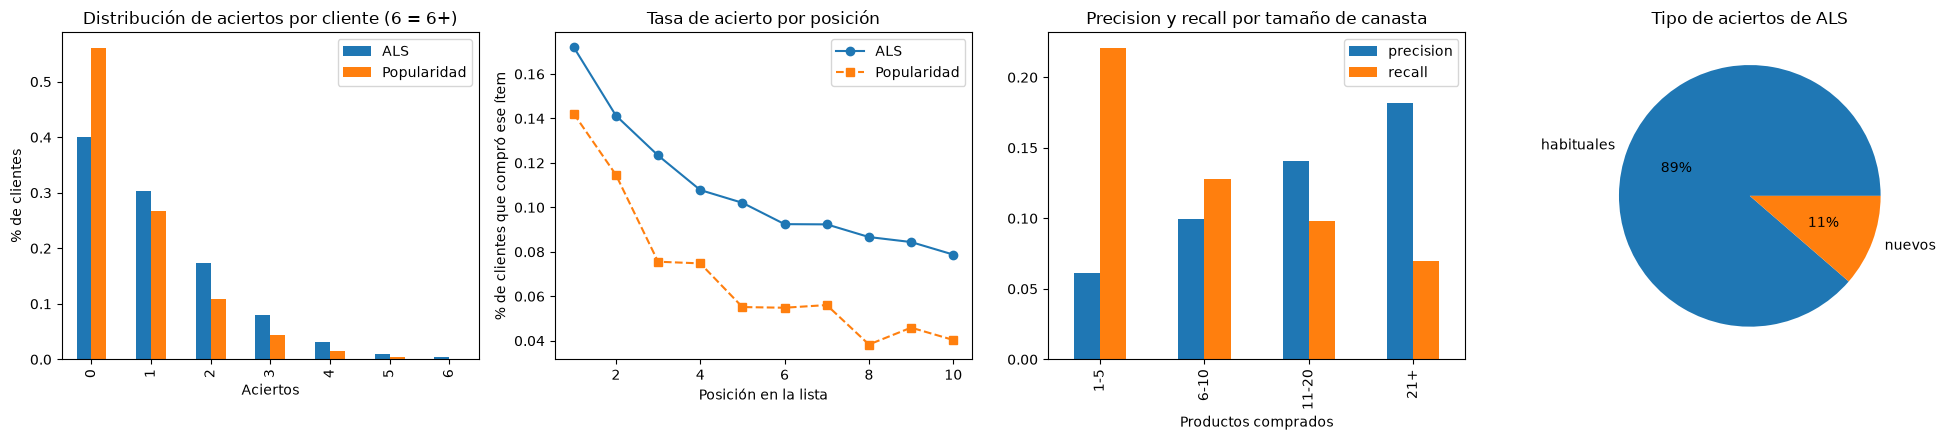

In [105]:
# ---------------------------------------------------------------------
# DIAGNÓSTICO: ¿ESTAMOS PREDICIENDO CORRECTAMENTE?
# Usa: recs_als, recs_pop, valid, inter_aj (bloque 4)
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt

comprados_hist = inter_aj.groupby("user_id").product_id.apply(set)

def diagnostico(recs, reales, k=10):
    filas = []
    for u, real in reales.items():
        lista = recs[u][:k]
        hist_u = comprados_hist.get(u, set())
        aciertos_pos = [p in real for p in lista]
        filas.append({
            "compró": len(real),
            "aciertos": sum(aciertos_pos),
            "habituales": sum(1 for p in lista if p in real and p in hist_u),
            "nuevos": sum(1 for p in lista if p in real and p not in hist_u),
            **{f"pos{i+1}": int(h) for i, h in enumerate(aciertos_pos)},
        })
    return pd.DataFrame(filas)

d_als, d_pop = diagnostico(recs_als, valid), diagnostico(recs_pop, valid)
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

# ---- 1. ¿A cuántos clientes les acertamos al menos 1 producto? -------
# NEGOCIO: un cliente sin ningún acierto ve un carrusel inútil.
cob_als, cob_pop = (d_als.aciertos > 0).mean(), (d_pop.aciertos > 0).mean()
print(f"1. Clientes con ≥ 1 acierto  → ALS {cob_als:.1%} | Popularidad {cob_pop:.1%}")

# ---- 2. ¿Cuántos aciertos por cliente? -------------------------------
dist = pd.DataFrame({"ALS": d_als.aciertos.clip(upper=6).value_counts(normalize=True),
                     "Popularidad": d_pop.aciertos.clip(upper=6).value_counts(normalize=True)}).sort_index()
dist.plot.bar(ax=ax[0], title="Distribución de aciertos por cliente (6 = 6+)")
ax[0].set_xlabel("Aciertos"); ax[0].set_ylabel("% de clientes")
print(f"   Clientes con 0 aciertos → ALS {(d_als.aciertos == 0).mean():.1%}")

# ---- 3. ¿El orden tiene sentido? (la prueba clave del ranking) -------
# TÉCNICO: si el modelo ordena bien, la posición 1 debe acertar MÁS que la 10.
#   Una línea que baja = el modelo sabe qué es lo más probable.
#   Una línea plana = acierta, pero no sabe ordenar.
tasa_pos_als = d_als[[f"pos{i}" for i in range(1, 11)]].mean().values
tasa_pos_pop = d_pop[[f"pos{i}" for i in range(1, 11)]].mean().values
ax[1].plot(range(1, 11), tasa_pos_als, "o-", label="ALS")
ax[1].plot(range(1, 11), tasa_pos_pop, "s--", label="Popularidad")
ax[1].set_title("Tasa de acierto por posición"); ax[1].set_xlabel("Posición en la lista")
ax[1].set_ylabel("% de clientes que compró ese ítem"); ax[1].legend()
print(f"2. Acierto en posición 1: {tasa_pos_als[0]:.1%} | posición 10: {tasa_pos_als[-1]:.1%} "
      f"→ {'el orden SÍ tiene sentido' if tasa_pos_als[0] > tasa_pos_als[-1] * 1.5 else 'el orden casi no discrimina'}")

# ---- 4. ¿Predecimos mejor según el tamaño de la canasta? -------------
tramos = pd.cut(d_als.compró, [0, 5, 10, 20, 200], labels=["1-5", "6-10", "11-20", "21+"])
por_tramo = d_als.groupby(tramos, observed=True).agg(
    clientes=("aciertos", "size"), aciertos=("aciertos", "mean"),
    precision=("aciertos", lambda s: s.mean() / 10),
    recall=("aciertos", lambda s: (s / d_als.loc[s.index, "compró"]).mean()))
por_tramo[["precision", "recall"]].plot.bar(ax=ax[2], title="Precision y recall por tamaño de canasta")
ax[2].set_xlabel("Productos comprados")
print("\n3. Por tamaño de canasta:")
print(por_tramo.round(3).to_string())

# ---- 5. ¿Qué tipo de aciertos logramos? ------------------------------
# NEGOCIO: habitual = ahorra tiempo al cliente; nuevo = venta incremental.
tot = d_als[["habituales", "nuevos"]].sum()
tot.plot.pie(ax=ax[3], autopct="%1.0f%%", title="Tipo de aciertos de ALS")
ax[3].set_ylabel("")
print(f"\n4. De los aciertos de ALS: {tot.habituales / tot.sum():.0%} habituales, "
      f"{tot.nuevos / tot.sum():.0%} nuevos")

plt.tight_layout(); plt.show()

Best trial: 38. Best value: 0.290507: 100%|██████████| 40/40 [00:54<00:00,  1.36s/it]

TOP 5 CONFIGURACIONES (validación):
     B      K1  alpha  factores  iters metodo    reg  ndcg@10  nuevos_x_usuario  precision@10  recall@10
0.5393 54.3644 1.0232       256     10   bm25 0.3719   0.2905            0.0242        0.2106     0.2648
0.5054 53.8321 1.2270       256     10   bm25 0.0751   0.2904            0.0264        0.2105     0.2661
0.7210 92.3006 1.6916       256     10   bm25 0.1301   0.2894            0.0242        0.2116     0.2714
0.6634 77.8907 1.4682       256     10   bm25 0.7420   0.2878            0.0246        0.2102     0.2683
0.5878 60.0962 1.3740       256     10   bm25 0.4287   0.2871            0.0253        0.2089     0.2659

MEJOR: {'metodo': 'bm25', 'alpha': 1.0232087836504542, 'factores': 256, 'reg': 0.3718532329245397, 'iters': 10, 'K1': 54.364407732547704, 'B': 0.5392565787858808}
→ INSIGHT: NDCG@10 pasa de 0.1564 (inicial) a 0.2905 (+85.7%). Nuevos por usuario: 0.123 → 0.024

IMPORTANCIA DE PARÁMETROS:
   alpha      ████████████████ 41%
   K1     

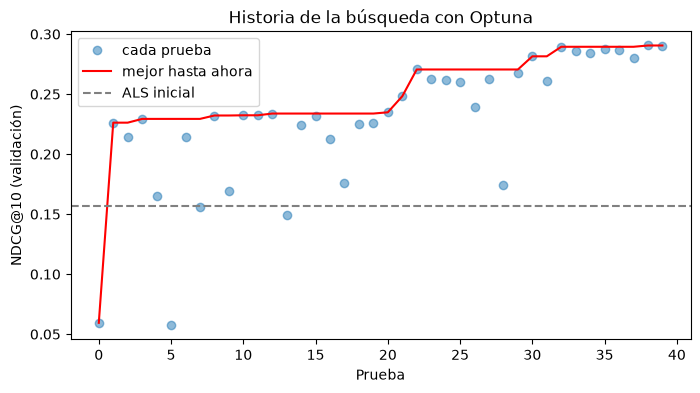

In [124]:
# =====================================================================
# BLOQUE 5 — AJUSTE DE HIPERPARÁMETROS CON OPTUNA
# Usa: M_aj, u2i_aj, i2p_aj, inter_aj, valid, respaldo, entrenar_als,
#      recomendar, evaluar (bloque 4)
# Regla: se optimiza contra VALIDACIÓN (orden n-1). El test no se toca.
# =====================================================================
# pip install optuna
import optuna, contextlib, io
from implicit.nearest_neighbours import bm25_weight

# ---------------------------------------------------------------------
# 5.1 PONDERACIÓN con BM25 ajustable
# TÉCNICO: BM25 tiene dos perillas propias:
#   K1 → qué tan rápido "se satura" la confianza al repetir compras
#   B  → cuánto se penaliza a los usuarios que compran de todo
#   Además baja el peso de productos que compra todo el mundo (bananas).
# NEGOCIO: empuja al modelo hacia gustos PERSONALES y menos obvios,
#   que es lo que debería mejorar el descubrimiento.
# ---------------------------------------------------------------------
def ponderar(M, metodo="log", alpha=15, K1=100, B=0.8):
    C = M.copy().astype("float32")
    if metodo == "log":
        C.data = 1 + alpha * np.log1p(C.data)
    else:
        C = (bm25_weight(C, K1=K1, B=B) * alpha).tocsr()
    return C.tocsr()

# ---------------------------------------------------------------------
# 5.2 FUNCIÓN OBJETIVO: lo que Optuna intenta maximizar
# TÉCNICO: en cada prueba (trial), Optuna propone parámetros, entrenamos,
#   medimos NDCG@10 en validación y se lo devolvemos.
#   Guardamos también precision, recall y nuevos para analizarlos después.
# NEGOCIO: NDCG es la métrica guía porque premia acertar ARRIBA,
#   que es lo que el cliente ve en la app sin hacer scroll.
# ---------------------------------------------------------------------
usuarios_val = list(valid.index)

def objetivo(trial):
    metodo = trial.suggest_categorical("metodo", ["log", "bm25"])
    params = {
        "alpha":    trial.suggest_float("alpha", 1, 100, log=True),       # escala log: prueba 1, 3, 10, 30, 100…
        "factores": trial.suggest_categorical("factores", [32, 64, 128, 256]),
        "reg":      trial.suggest_float("reg", 1e-3, 1.0, log=True),
        "iters":    trial.suggest_int("iters", 10, 30, step=5),
    }
    # Parámetros que solo existen si el método es BM25 (espacio condicional)
    K1 = trial.suggest_float("K1", 20, 300, log=True) if metodo == "bm25" else 100
    B  = trial.suggest_float("B", 0.3, 1.0) if metodo == "bm25" else 0.8

    C = ponderar(M_aj, metodo, params["alpha"], K1, B)
    modelo = entrenar_als(C, params["factores"], params["reg"], params["iters"], verbose=False)
    with contextlib.redirect_stdout(io.StringIO()):                # silencia el aviso del usuario sin perfil
        recs = recomendar(modelo, C, u2i_aj, i2p_aj, usuarios_val, respaldo)
    m = evaluar(recs, valid, inter_aj)

    for nombre, valor in m.items():                                 # guardar todas las métricas
        trial.set_user_attr(nombre, valor)
    return m["ndcg@10"]

# ---------------------------------------------------------------------
# 5.3 EJECUTAR LA BÚSQUEDA
# TÉCNICO: sampler TPE (el algoritmo "inteligente" de Optuna) con semilla
#   fija = búsqueda reproducible. 40 pruebas ≈ unos minutos.
# ---------------------------------------------------------------------
optuna.logging.set_verbosity(optuna.logging.WARNING)
estudio = optuna.create_study(direction="maximize", study_name="als_instacart",
                              sampler=optuna.samplers.TPESampler(seed=42))
estudio.optimize(objetivo, n_trials=40, show_progress_bar=True)

# ---------------------------------------------------------------------
# 5.4 RESULTADOS
# ---------------------------------------------------------------------
pruebas = estudio.trials_dataframe()
cols_metricas = [c for c in pruebas.columns if c.startswith("user_attrs_")]
cols_params   = [c for c in pruebas.columns if c.startswith("params_")]
top = (pruebas.sort_values("value", ascending=False)[cols_params + cols_metricas]
              .rename(columns=lambda c: c.replace("params_", "").replace("user_attrs_", "")))
print("TOP 5 CONFIGURACIONES (validación):")
print(top.head(5).round(4).to_string(index=False))

mejor = estudio.best_trial
inicial = val_tabla.loc["ALS inicial"]
print(f"\nMEJOR: {mejor.params}")
print(f"→ INSIGHT: NDCG@10 pasa de {inicial['ndcg@10']:.4f} (inicial) a {mejor.value:.4f} "
      f"({mejor.value / inicial['ndcg@10'] - 1:+.1%}). "
      f"Nuevos por usuario: {inicial['nuevos_x_usuario']:.3f} → {mejor.user_attrs['nuevos_x_usuario']:.3f}")

# ---------------------------------------------------------------------
# 5.5 ¿QUÉ PARÁMETROS IMPORTAN? (respuesta típica de entrevista)
# TÉCNICO: Optuna estima qué parámetro explica más la variación del NDCG.
# NEGOCIO: dice dónde vale la pena invertir tiempo de ajuste y dónde no.
# ---------------------------------------------------------------------
importancia = optuna.importance.get_param_importances(estudio)
print("\nIMPORTANCIA DE PARÁMETROS:")
for p, v in importancia.items():
    print(f"   {p:10s} {'█' * int(v * 40)} {v:.0%}")

# Gráfico de la historia de la búsqueda
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pruebas.number, pruebas.value, "o", alpha=0.5, label="cada prueba")
ax.plot(pruebas.number, pruebas.value.cummax(), "r-", label="mejor hasta ahora")
ax.axhline(inicial["ndcg@10"], color="gray", ls="--", label="ALS inicial")
ax.set_xlabel("Prueba"); ax.set_ylabel("NDCG@10 (validación)"); ax.legend()
ax.set_title("Historia de la búsqueda con Optuna"); plt.show()

In [126]:
# Recompra: los 10 productos que cada usuario más compró (órdenes 1…n-2)
recs_recompra = (inter_aj.sort_values(["user_id", "veces"], ascending=[True, False])
                 .groupby("user_id").product_id.apply(lambda s: s.head(10).tolist()).to_dict())
for u in valid.index:                                    # usuario sin historial → popularidad
    recs_recompra.setdefault(u, respaldo[:10])

val_tabla.loc["Recompra"] = pd.Series(evaluar(recs_recompra, valid, inter_aj))
val_tabla.loc["ALS ajustado"] = pd.Series({k: estudio.best_trial.user_attrs[k] for k in val_tabla.columns})
print(val_tabla.round(4).to_string())

              precision@10  recall@10  ndcg@10  nuevos_x_usuario
Popularidad         0.0698     0.0680   0.0953            0.1294
ALS inicial         0.1081     0.1416   0.1564            0.1228
Recompra            0.2622     0.3201   0.3838            0.0000
ALS ajustado        0.2106     0.2648   0.2905            0.0242


In [127]:
# =====================================================================
# BLOQUE 5B — OPTUNA PARA EL CARRUSEL "DESCUBRE ALGO NUEVO"
# =====================================================================
comprados_aj = inter_aj.groupby("user_id").product_id.apply(set).to_dict()

# --- Verdad de terreno: solo productos NUEVOS de la orden n-1 ---
valid_nuevos = pd.Series({u: s - comprados_aj.get(u, set()) for u, s in valid.items()})
valid_nuevos = valid_nuevos[valid_nuevos.apply(len) > 0]
print(f"Clientes que compraron ≥ 1 producto nuevo: {len(valid_nuevos):,} de {len(valid):,} "
      f"({len(valid_nuevos)/len(valid):.0%})")
usuarios_nv = list(valid_nuevos.index)

# --- Recomendar FILTRANDO lo ya comprado ---
def recomendar_nuevos(modelo, C, usuarios, n=10):
    conocidos = [u for u in usuarios if u in u2i_aj]
    filas = np.array([u2i_aj[u] for u in conocidos])
    idx, _ = modelo.recommend(filas, C[filas], N=n, filter_already_liked_items=True)
    recs = {u: i2p_aj[idx[k]].tolist() for k, u in enumerate(conocidos)}
    for u in usuarios:                                   # sin perfil → popularidad
        recs.setdefault(u, respaldo[:n])
    return recs

# --- Línea base justa: popularidad SIN lo que ya compra ---
pop_larga = top_popular(inter_aj, n=200)
recs_pop_nv = {u: [p for p in pop_larga if p not in comprados_aj.get(u, set())][:10]
               for u in usuarios_nv}

# --- Objetivo: NDCG sobre productos nuevos ---
def objetivo_nuevos(trial):
    metodo = trial.suggest_categorical("metodo", ["log", "bm25"])
    alpha  = trial.suggest_float("alpha", 0.1, 100, log=True)          # rango ampliado
    fact   = trial.suggest_categorical("factores", [32, 64, 128, 256, 512])
    reg    = trial.suggest_float("reg", 1e-3, 1.0, log=True)
    iters  = trial.suggest_int("iters", 5, 30, step=5)
    K1 = trial.suggest_float("K1", 20, 300, log=True) if metodo == "bm25" else 100
    B  = trial.suggest_float("B", 0.3, 1.0) if metodo == "bm25" else 0.8

    C = ponderar(M_aj, metodo, alpha, K1, B)
    modelo = entrenar_als(C, fact, reg, iters, verbose=False)
    recs = recomendar_nuevos(modelo, C, usuarios_nv)
    m = evaluar(recs, valid_nuevos, inter_aj)
    for k, v in m.items():
        trial.set_user_attr(k, v)
    return m["ndcg@10"]

estudio_nv = optuna.create_study(direction="maximize", study_name="als_descubrimiento",
                                 sampler=optuna.samplers.TPESampler(seed=42))
estudio_nv.optimize(objetivo_nuevos, n_trials=40, show_progress_bar=True)

# --- Comparación ---
tabla_nv = pd.DataFrame({
    "Popularidad nueva para ti": evaluar(recs_pop_nv, valid_nuevos, inter_aj),
    "ALS descubrimiento":        estudio_nv.best_trial.user_attrs,
}).T[["precision@10", "recall@10", "ndcg@10"]]
print("\nCARRUSEL 'DESCUBRE ALGO NUEVO' (validación, solo productos nuevos):")
print(tabla_nv.round(4).to_string())
print(f"\nMejores parámetros: {estudio_nv.best_params}")
mejora = tabla_nv.loc["ALS descubrimiento", "ndcg@10"] / tabla_nv.loc["Popularidad nueva para ti", "ndcg@10"] - 1
print(f"→ INSIGHT: en descubrimiento, ALS supera a la popularidad en {mejora:+.0%} de NDCG@10.")

Clientes que compraron ≥ 1 producto nuevo: 16,636 de 20,000 (83%)


Best trial: 36. Best value: 0.0403078: 100%|██████████| 40/40 [00:44<00:00,  1.11s/it]



CARRUSEL 'DESCUBRE ALGO NUEVO' (validación, solo productos nuevos):
                           precision@10  recall@10  ndcg@10
Popularidad nueva para ti        0.0199     0.0386   0.0331
ALS descubrimiento               0.0240     0.0500   0.0403

Mejores parámetros: {'metodo': 'bm25', 'alpha': 0.4443355888089772, 'factores': 32, 'reg': 0.002039655849286232, 'iters': 15, 'K1': 68.93167842075032, 'B': 0.33345102000960325}
→ INSIGHT: en descubrimiento, ALS supera a la popularidad en +22% de NDCG@10.


In [128]:
n = 1000
for modelo in tabla_nv.index:
    aciertos = tabla_nv.loc[modelo, "precision@10"] * 10 * n
    print(f"{modelo:28s} → de {n:,} clientes, acierta {aciertos:,.0f} productos NUEVOS")

Popularidad nueva para ti    → de 1,000 clientes, acierta 199 productos NUEVOS
ALS descubrimiento           → de 1,000 clientes, acierta 240 productos NUEVOS
